# NB32 — CPU comparison report

Use CPU, Internet ON, HF_TOKEN enabled. No dataset attachment needed. Run All after NB31 completes all three seeds. Reads small frozen HRNet and fresh SegFormer metric files, checks identical targets, and publishes the paired report and chart to HF.

## What is matched—and what is not

The frozen HRNet allocation is reused exactly: 72 training / 24 validation / 24 test images,
from 8 / 2 / 2 user-confirmed different tyres. Seeds 1–3, 60 epochs, batch 2, input
512×384, AdamW 0.0001, cosine schedule, no augmentation, and final-epoch evaluation.
SegFormer-B0 starts from pinned ImageNet MiT-B0 weights, NOT an old S5 checkpoint.
It learns from the **existing dense masks on the same 72 training images**; HRNet
learned from six clicked points. Same evaluation annotations, different training supervision.
This is an exploratory system comparison, not an equal-supervision architecture claim.

No new annotations and no HRNet rerun. Only two test tyres; no significance or full-S9 claim.


## 1. Credentials and isolated runtime
The embedded source is versioned with the experiment contract.

In [4]:
import os, sys, subprocess, base64, signal
from pathlib import Path
WORK=Path('/kaggle/working/segformer_matched');WORK.mkdir(exist_ok=True)
from kaggle_secrets import UserSecretsClient
TOKEN=UserSecretsClient().get_secret('HF_TOKEN')
assert TOKEN, 'Enable HF_TOKEN in Kaggle Secrets before Run All'
(WORK/'segformer_matched.py').write_bytes(base64.b64decode('...'))
(WORK/'hrnet_runtime.py').write_bytes(base64.b64decode('...'))
(WORK/'hrnet_protocol.py').write_bytes(base64.b64decode('IiIiRnJvemVuLCB1c2VyLWlkZW50aXR5LWNvbmZpcm1lZCBIUk5ldCBnZW9tZXRyeSBleHBlcmltZW50LiBDUFUgcHJlZmxpZ2h0LiIiIgppbXBvcnQgY29sbGVjdGlvbnMKaW1wb3J0IGhhc2hsaWIKaW1wb3J0IGl0ZXJ0b29scwppbXBvcnQganNvbgpmcm9tIHBhdGhsaWIgaW1wb3J0IFBhdGgKaW1wb3J0IHNodXRpbAppbXBvcnQgdGltZQppbXBvcnQgcmVxdWVzdHMKZnJvbSBQSUwgaW1wb3J0IEltYWdlLCBJbWFnZURyYXcKClJFUE89J1NoYW5tdWs0NjIyL3R5cmUtd2Vhci1zdHVkeScKUkVWPScyYjQ3NzM5MTRlNmVlZmU0MjFkOGRkZDc0ZTc5YzViODQ2MDZjOWFhJwpQQUNLQUdFPScxMDBkYWM1YjEyZTExOTJlZGU1OWY5ZDEyMzFjNWFlZWVkODA0Mjg4NTA2NjFhOWFkZDFjYmExNDdmZTIyZjkyJwpBTk49JzhlOGZkMDczNGI5ZjRmZTQyMzZlNjk5YjgwNGMyZjhhZmI4NWFlNGJiODQ3ZjhkM2M4M2IwYWJmZjVhODc2OWUnCkJBU0U9ZidzOS9zOS1nZW9tZXRyeS1sYWJlbHMtcjItYWxsMTIwL3BhY2thZ2VzL3tQQUNLQUdFfScKVkVSU0lPTj0naHJuZXQtZ2VvbWV0cnktMjAyNi0wOS0xNS1yMScKUE9JTlRTPVsnbGVmdF91cHBlcicsJ3JpZ2h0X3VwcGVyJywnbGVmdF9taWRkbGUnLCdyaWdodF9taWRkbGUnLCdsZWZ0X2xvd2VyJywncmlnaHRfbG93ZXInXQpkZWYgY2Fub25pY2FsKHgpOnJldHVybiBqc29uLmR1bXBzKHgsc29ydF9rZXlzPVRydWUsc2VwYXJhdG9ycz0oJywnLCc6JyksZW5zdXJlX2FzY2lpPUZhbHNlKS5lbmNvZGUoKQpkZWYgc2hhKHgpOnJldHVybiBoYXNobGliLnNoYTI1Nih4KS5oZXhkaWdlc3QoKQpkZWYgZmlsZV9zaGEocGF0aCk6CiAgICBoPWhhc2hsaWIuc2hhMjU2KCkKICAgIHdpdGggb3BlbihwYXRoLCdyYicpIGFzIGY6CiAgICAgICAgZm9yIGIgaW4gaXRlcihsYW1iZGE6Zi5yZWFkKDEwMjQqKjIpLGInJyk6aC51cGRhdGUoYikKICAgIHJldHVybiBoLmhleGRpZ2VzdCgpCmRlZiB3cml0ZShwYXRoLHgpOgogICAgcGF0aD1QYXRoKHBhdGgpO3BhdGgucGFyZW50Lm1rZGlyKHBhcmVudHM9VHJ1ZSxleGlzdF9vaz1UcnVlKQogICAgdG1wPXBhdGgud2l0aF9zdWZmaXgocGF0aC5zdWZmaXgrJy50bXAnKTt0bXAud3JpdGVfYnl0ZXMoY2Fub25pY2FsKHgpKTt0bXAucmVwbGFjZShwYXRoKQpkZWYgcmVhZF9qc29uKHBhdGgpOnJldHVybiBqc29uLmxvYWRzKFBhdGgocGF0aCkucmVhZF90ZXh0KGVuY29kaW5nPSd1dGYtOCcpKQpkZWYgcmV0cnkoZm4pOgogICAgZm9yIGkgaW4gcmFuZ2UoNik6CiAgICAgICAgdHJ5OnJldHVybiBmbigpCiAgICAgICAgZXhjZXB0IEV4Y2VwdGlvbiBhcyBlOgogICAgICAgICAgICByZXNwb25zZT1nZXRhdHRyKGUsJ3Jlc3BvbnNlJyxOb25lKTtjb2RlPWdldGF0dHIocmVzcG9uc2UsJ3N0YXR1c19jb2RlJyxOb25lKQogICAgICAgICAgICBpZiBjb2RlIG5vdCBpbiAoTm9uZSw0MjksNTAwLDUwMiw1MDMsNTA0KSBvciBpPT01OnJhaXNlCiAgICAgICAgICAgIGhpbnQ9Z2V0YXR0cihyZXNwb25zZSwnaGVhZGVycycse30pLmdldCgnUmV0cnktQWZ0ZXInLCcwJykKICAgICAgICAgICAgZGVsYXk9bWF4KDEwKjIqKmksZmxvYXQoaGludCkgaWYgc3RyKGhpbnQpLmlzZGlnaXQoKSBlbHNlIDApCiAgICAgICAgICAgIHByaW50KGYnSEYgcmV0cnkgYWZ0ZXIge2RlbGF5Oi4wZn1zOyBkdXJhYmxlIGxvY2FsIHN0YXRlIHJldGFpbmVkLicsZmx1c2g9VHJ1ZSkKICAgICAgICAgICAgdW50aWw9dGltZS5tb25vdG9uaWMoKStkZWxheQogICAgICAgICAgICB3aGlsZSB0aW1lLm1vbm90b25pYygpPHVudGlsOnRpbWUuc2xlZXAobWF4KDAsbWluKDUsdW50aWwtdGltZS5tb25vdG9uaWMoKSkpKQpkZWYgc291cmNlKHBhdGgsd29yayk6CiAgICBkZXN0PVBhdGgod29yaykvJ3NvdXJjZXMnL3NoYShwYXRoLmVuY29kZSgpKTtkZXN0LnBhcmVudC5ta2RpcihwYXJlbnRzPVRydWUsZXhpc3Rfb2s9VHJ1ZSkKICAgIGlmIG5vdCBkZXN0LmV4aXN0cygpOgogICAgICAgIGRlZiBkb3dubG9hZCgpOgogICAgICAgICAgICB3aXRoIHJlcXVlc3RzLmdldChmJ2h0dHBzOi8vaHVnZ2luZ2ZhY2UuY28vZGF0YXNldHMve1JFUE99L3Jlc29sdmUve1JFVn0ve0JBU0V9L3twYXRofScsdGltZW91dD00NSxzdHJlYW09VHJ1ZSkgYXMgcjoKICAgICAgICAgICAgICAgIHIucmFpc2VfZm9yX3N0YXR1cygpO2I9Ynl0ZWFycmF5KCkKICAgICAgICAgICAgICAgIGZvciBjaHVuayBpbiByLml0ZXJfY29udGVudCg2NTUzNik6CiAgICAgICAgICAgICAgICAgICAgYi5leHRlbmQoY2h1bmspCiAgICAgICAgICAgICAgICAgICAgaWYgbGVuKGIpPjIqMTAyNCoqMjpyYWlzZSBWYWx1ZUVycm9yKCdNZXRhZGF0YSBjYXAgZXhjZWVkZWQnKQogICAgICAgICAgICByZXR1cm4gYgogICAgICAgIHJhdz1yZXRyeShkb3dubG9hZCk7dG1wPWRlc3Qud2l0aF9zdWZmaXgoJy50bXAnKTt0bXAud3JpdGVfYnl0ZXMocmF3KTt0bXAucmVwbGFjZShkZXN0KQogICAgcmV0dXJuIGRlc3QucmVhZF9ieXRlcygpCmRlZiBzcGxpdF9ncm91cHMoaW1hZ2VzKToKICAgICIiIjgvMi8yIHR5cmVzOyBjaG9vc2UgaW1hZ2UtY291bnQgYmFsYW5jZSwgdGhlbiBhIGZpeGVkIGhhc2ggdGllLWJyZWFrIG9ubHkuIiIiCiAgICBjb3VudHM9Y29sbGVjdGlvbnMuQ291bnRlcihyWydzZXNzaW9uJ10gZm9yIHIgaW4gaW1hZ2VzKTtncm91cHM9c29ydGVkKGNvdW50cykKICAgIGFzc2VydCBsZW4oZ3JvdXBzKT09MTIKICAgIG9wdGlvbnM9W10KICAgIGZvciB0ZXN0IGluIGl0ZXJ0b29scy5jb21iaW5hdGlvbnMoZ3JvdXBzLDIpOgogICAgICAgIGZvciBkZXYgaW4gaXRlcnRvb2xzLmNvbWJpbmF0aW9ucyhbZyBmb3IgZyBpbiBncm91cHMgaWYgZyBub3QgaW4gdGVzdF0sMik6CiAgICAgICAgICAgIG50PXN1bShjb3VudHNbZ10gZm9yIGcgaW4gdGVzdCk7bnY9c3VtKGNvdW50c1tnXSBmb3IgZyBpbiBkZXYpCiAgICAgICAgICAgIGlmIG1pbihudCxudik8MTI6Y29udGludWUKICAgICAgICAgICAga2V5PShhYnMobnQtMjQpK2Ficyhudi0yNCksc2hhKGNhbm9uaWNhbChbdGVzdCxkZXZdKSkpCiAgICAgICAgICAgIG9wdGlvbnMuYXBwZW5kKChrZXksbGlzdCh0ZXN0KSxsaXN0KGRldikpKQogICAgXyx0ZXN0LGRldj1taW4ob3B0aW9ucykKICAgIHJldHVybiBkaWN0KHRyYWluPVtnIGZvciBnIGluIGdyb3VwcyBpZiBnIG5vdCBpbiB0ZXN0K2Rldl0sdmFsaWRhdGlvbj1kZXYsdGVzdD10ZXN0KQpkZWYgY29udHJhY3Qod29yayk6CiAgICByYXc9c291cmNlKGYncmV2aWV3cy97QU5OfS9BTk5PVEFUSU9OUy5qc29uJyx3b3JrKTthc3NlcnQgc2hhKHJhdyk9PUFOTgogICAgbGFiZWxzPWpzb24ubG9hZHMocmF3KTttYW5pZmVzdD1qc29uLmxvYWRzKHNvdXJjZSgnTUFOSUZFU1QuanNvbicsd29yaykpCiAgICBhc3NlcnQgc2hhKGNhbm9uaWNhbCh7azp2IGZvciBrLHYgaW4gbWFuaWZlc3QuaXRlbXMoKSBpZiBrIT0ncGFja2FnZV9pZCd9KSk9PVBBQ0tBR0UKICAgIGltcG9ydCBzOV9leHBhbnNpb24gYXMgZQogICAgY2hlY2tzPWUudmFsaWRhdGUobGFiZWxzLG1hbmlmZXN0KQogICAgYXNzZXJ0IGxlbihjaGVja3MpPT0xMjAgYW5kIGFsbChyWydjb21wbGV0ZSddIGZvciByIGluIGNoZWNrcykKICAgIGJ5X2lkPXtyWydwaWxvdF9pZCddOnIgZm9yIHIgaW4gbGFiZWxzWydhbm5vdGF0aW9ucyddfQogICAgYXNzZXJ0IGFsbChieV9pZFtyWydwaWxvdF9pZCddXVsncG9pbnRzJ11bbl1bJ3N0YXRlJ109PSd2aXNpYmxlJyBmb3IgciBpbiBtYW5pZmVzdFsnaW1hZ2VzJ10gZm9yIG4gaW4gUE9JTlRTKSwgJ1RoaXMgcHJvdG9jb2wgaXMgY29vcmRpbmF0ZS1vbmx5IGZvciB0aGUgZnJvemVuIGFsbC12aXNpYmxlIHN1Ym1pc3Npb24nCiAgICBncm91cHM9c3BsaXRfZ3JvdXBzKG1hbmlmZXN0WydpbWFnZXMnXSkKICAgIHJvd3M9W10KICAgIGZvciByZWYgaW4gbWFuaWZlc3RbJ2ltYWdlcyddOgogICAgICAgIGE9YnlfaWRbcmVmWydwaWxvdF9pZCddXQogICAgICAgIHJvbGU9bmV4dChrIGZvciBrLHYgaW4gZ3JvdXBzLml0ZW1zKCkgaWYgcmVmWydzZXNzaW9uJ10gaW4gdikKICAgICAgICByb3dzLmFwcGVuZChyZWZ8ZGljdChyb2xlPXJvbGUseD1bYVsncG9pbnRzJ11bbl1bJ3gnXS8ocmVmWyd3aWR0aCddLTEpIGZvciBuIGluIFBPSU5UU10pKQogICAgY2ZnPWRpY3QodmVyc2lvbj1WRVJTSU9OLHNvdXJjZV9yZXZpc2lvbj1SRVYsYW5ub3RhdGlvbnNfc2hhMjU2PUFOTixwYWNrYWdlX2lkPVBBQ0tBR0UsCiAgICAgICAgaWRlbnRpdHk9ZGljdChzb3VyY2U9J1VzZXIgY29uZmlybWF0aW9uIGluIHByb2plY3QgY29udmVyc2F0aW9uLCAxNSBTZXB0ZW1iZXIgMjAyNicsCiAgICAgICAgICAgIGFzc2VydGlvbj0nMTIgY2FwdHVyZSBzZXNzaW9ucyByZXByZXNlbnQgMTIgZGlmZmVyZW50IHBoeXNpY2FsIHR5cmVzJyxpbmRlcGVuZGVudGx5X3ZlcmlmaWVkPUZhbHNlKSwKICAgICAgICBncm91cHM9Z3JvdXBzLHJvd3M9cm93cyxwb2ludF9uYW1lcz1QT0lOVFMsCiAgICAgICAgbW9kZWw9J2hybmV0X3cxOC5tc19hdWdfaW4xaycsZmVhdHVyZV9sb2NhdGlvbj0nJyxmZWF0dXJlX2luZGljZXM9WzEsMiwzLDRdLAogICAgICAgIHByZXRyYWluZWRfcmVwbz0ndGltbS9ocm5ldF93MTgubXNfYXVnX2luMWsnLHByZXRyYWluZWRfcmV2aXNpb249JzdlMmM1NTgzNzY5ZjU0NTE0ZmQ4N2UzYmE5ZGU0MDhlMzNlYWJhMGYnLAogICAgICAgIHBhY2thZ2VzPXsndGltbSc6JzEuMC4xNSd9LGlucHV0X2h3PVs1MTIsMzg0XSxiYXRjaF9zaXplPTIsZXBvY2hzPTYwLHNlZWRzPVsxLDIsM10sCiAgICAgICAgb3B0aW1pemVyPSdBZGFtVycsbHI9MC4wMDAxLHdlaWdodF9kZWNheT0wLjAxLGxyX3NjaGVkdWxlPSdjb3NpbmVfZXBvY2gnLAogICAgICAgIGF1Z21lbnRhdGlvbj0nbm9uZTsgZGV0ZXJtaW5pc3RpYyBpZGVudGl0eSB0cmFuc2Zvcm0nLGJhdGNobm9ybT0nZnJvemVuIHJ1bm5pbmcgc3RhdGlzdGljcycsCiAgICAgICAgbG9zcz0nc2l4IGhvcml6b250YWwgR2F1c3NpYW4gdGFyZ2V0cywgc2lnbWE9MS41IGZlYXR1cmUgcGl4ZWxzOyBtZWFuIGNyb3NzIGVudHJvcHknLAogICAgICAgIGVuZHBvaW50PSdmaXhlZCBlcG9jaCA2MDsgbm8gYmVzdC10ZXN0IG9yIGJlc3QtdmFsaWRhdGlvbiBjaGVja3BvaW50IHNlbGVjdGlvbicsCiAgICAgICAgdmlzaWJpbGl0eT0nYWxsIGxhYmVscyB2aXNpYmxlOyBubyB2aXNpYmlsaXR5IGNsYXNzaWZpZXIgb3IgcmVqZWN0aW9uIHZhbGlkYXRpb24nLAogICAgICAgIHFhPSdtZWNoYW5pY2FsIGNoZWNrcyBhbmQgcmV2aWV3IGRpYWdyYW1zOyBodW1hbiBhY2N1cmFjeSBub3QgY2VydGlmaWVkJywKICAgICAgICBzY3JpcHRzPXtuOmZpbGVfc2hhKFBhdGgoX19maWxlX18pLnBhcmVudC9uKSBmb3IgbiBpbiBbJ2hybmV0X3Byb3RvY29sLnB5JywnaHJuZXRfcnVudGltZS5weScsJ3M5X2V4cGFuc2lvbi5weScsJ3M5X3BpbG90LnB5J119LAogICAgICAgIGxpbWl0YXRpb25zPVsnb25seSAxMiB1c2VyLWNvbmZpcm1lZCB0eXJlczsgc21hbGwgdHdvLXR5cmUgdmFsaWRhdGlvbi90ZXN0IHNldHMnLAogICAgICAgICAgICAnb2xkIHBpbG90IGltYWdlcyB3ZXJlIGRldmVsb3BtZW50IGV2aWRlbmNlOyBzYW1lIHR5cmUgaWRlbnRpdGllcyB3ZXJlIHNlZW4gaW4gcGlsb3QgYW5hbHlzaXMnLAogICAgICAgICAgICAnbm90IHVudG91Y2hlZCBleHRlcm5hbC1jb2hvcnQgdmFsaWRhdGlvbjsgbm8gcGh5c2ljYWwgYW5nbGVzIG9yIGhlYWx0aHktcmVmZXJlbmNlIGluZmVyZW5jZScsCiAgICAgICAgICAgICdubyBtYXRjaGVkIHNlZ21lbnRhdGlvbiBjb21wYXJpc29uIHVudGlsIGJhc2VsaW5lIHRyYWluLXNldCBvdmVybGFwIGlzIHJlc29sdmVkJ10pCiAgICByZXR1cm4gY2ZnCmRlZiBwcmVmaXgoY2ZnKTpyZXR1cm4gZidzOS97VkVSU0lPTn0ve3NoYShjYW5vbmljYWwoY2ZnKSl9JwpkZWYgcm9vdF9kYXRhKHJvb3Q9JycpOgogICAgaWYgcm9vdDpyZXR1cm4gUGF0aChyb290KQogICAgZm91bmQ9bGlzdChQYXRoKCcva2FnZ2xlL2lucHV0JykuZ2xvYignKiovbWFuaWZlc3RzL2NsZWFuX21hbmlmZXN0LmNzdicpKQogICAgaWYgbGVuKGZvdW5kKSE9MTpyYWlzZSBWYWx1ZUVycm9yKCdBdHRhY2ggT05FIFRpcmUgRGF0YXNldCBQcmVwYXJlZCBkYXRhc2V0LCBvciBzZXQgREFUQV9ST09UIHRvIEZJTkFMJykKICAgIHJldHVybiBmb3VuZFswXS5wYXJlbnQucGFyZW50CmRlZiB2YWxpZGF0ZV9pbWFnZXMoY2ZnLHJvb3QpOgogICAgaGFzaGVzPXtrOnNldCgpIGZvciBrIGluIGNmZ1snZ3JvdXBzJ119CiAgICBmb3IgciBpbiBjZmdbJ3Jvd3MnXToKICAgICAgICBwYXRoPShQYXRoKHJvb3QpL3JbJ29yaWdpbmFsX3JlbGF0aXZlX3BhdGgnXSkucmVzb2x2ZSgpCiAgICAgICAgYXNzZXJ0IHBhdGguaXNfcmVsYXRpdmVfdG8oUGF0aChyb290KS5yZXNvbHZlKCkpCiAgICAgICAgYXNzZXJ0IGZpbGVfc2hhKHBhdGgpPT1yWydpbWFnZV9zaGEyNTYnXSxyWydwaWxvdF9pZCddKycgb3JpZ2luYWwgZGlmZmVycycKICAgICAgICB3aXRoIEltYWdlLm9wZW4ocGF0aCkgYXMgaW06YXNzZXJ0IGltLnNpemU9PShyWyd3aWR0aCddLHJbJ2hlaWdodCddKQogICAgICAgIGhhc2hlc1tyWydyb2xlJ11dLmFkZChyWydpbWFnZV9zaGEyNTYnXSkKICAgIGFzc2VydCBub3QgaGFzaGVzWyd0cmFpbiddJmhhc2hlc1sndmFsaWRhdGlvbiddIGFuZCBub3QgaGFzaGVzWyd0cmFpbiddJmhhc2hlc1sndGVzdCddIGFuZCBub3QgaGFzaGVzWyd0ZXN0J10maGFzaGVzWyd2YWxpZGF0aW9uJ10KZGVmIHB1Ymxpc2goZm9sZGVyLHBhdGgsdG9rZW4pOgogICAgZnJvbSBodWdnaW5nZmFjZV9odWIgaW1wb3J0IEhmQXBpCiAgICBmb2xkZXI9UGF0aChmb2xkZXIpCiAgICAjIE9uZSBzeW5jaHJvbm91cyB3cml0ZXI7IG5vIGNoZWNrcG9pbnQgY2hhbmdlcyBkdXJpbmcgdGhpcyBhdG9taWMgcmVwbyBjb21taXQuCiAgICByZXN1bHQ9cmV0cnkobGFtYmRhOkhmQXBpKHRva2VuPXRva2VuKS51cGxvYWRfZm9sZGVyKHJlcG9faWQ9UkVQTyxyZXBvX3R5cGU9J2RhdGFzZXQnLAogICAgICAgIGZvbGRlcl9wYXRoPXN0cihmb2xkZXIpLHBhdGhfaW5fcmVwbz1wYXRoLGlnbm9yZV9wYXR0ZXJucz1bJyoudG1wJywnKi5sb2NrJ10sCiAgICAgICAgY29tbWl0X21lc3NhZ2U9J0hSTmV0IGdlb21ldHJ5IGR1cmFibGUgc25hcHNob3QnKSkKICAgIHByaW50KCdIRiBwdWJsaWNhdGlvbiBzdWNjZWVkZWQ6JyxyZXN1bHQub2lkLGZsdXNoPVRydWUpO3JldHVybiByZXN1bHQub2lkCmRlZiBwcmVmbGlnaHQod29yayxyb290LHRva2VuLHVwbG9hZD1UcnVlKToKICAgIGNmZz1jb250cmFjdCh3b3JrKTt2YWxpZGF0ZV9pbWFnZXMoY2ZnLHJvb3QpCiAgICBmb2xkZXI9UGF0aCh3b3JrKS8ncHJlZmxpZ2h0Jy9zaGEoY2Fub25pY2FsKGNmZykpO2ZvbGRlci5ta2RpcihwYXJlbnRzPVRydWUsZXhpc3Rfb2s9VHJ1ZSkKICAgIHdyaXRlKGZvbGRlci8nQ09OVFJBQ1QuanNvbicsY2ZnKQogICAgY291bnRzPXtrOnN1bShyWydyb2xlJ109PWsgZm9yIHIgaW4gY2ZnWydyb3dzJ10pIGZvciBrIGluIGNmZ1snZ3JvdXBzJ119CiAgICBmbGFncz1bXQogICAgZm9yIHIgaW4gY2ZnWydyb3dzJ106CiAgICAgICAgIyBPcmlnaW5hbC1pbWFnZSBwb2ludCBvdmVybGF5czsgbm90IHN5bnRoZXRpYyBsYWJlbHMuIEV2ZXJ5IGltYWdlIGlzIGluY2x1ZGVkLgogICAgICAgIHdpdGggSW1hZ2Uub3BlbihQYXRoKHJvb3QpL3JbJ29yaWdpbmFsX3JlbGF0aXZlX3BhdGgnXSkgYXMgaW06CiAgICAgICAgICAgIGltPWltLmNvbnZlcnQoJ1JHQicpO2RyYXc9SW1hZ2VEcmF3LkRyYXcoaW0pCiAgICAgICAgICAgIGZvciBqLHggaW4gZW51bWVyYXRlKHJbJ3gnXSk6CiAgICAgICAgICAgICAgICB4eD14KihyWyd3aWR0aCddLTEpO3k9clsnZ3VpZGVfeSddW2ovLzJdCiAgICAgICAgICAgICAgICBkcmF3LmVsbGlwc2UoKHh4LTgseS04LHh4KzgseSs4KSxvdXRsaW5lPSdjeWFuJyx3aWR0aD0zKQogICAgICAgICAgICAgICAgaWYgbWluKHh4LHJbJ3dpZHRoJ10tMS14eCk8PTEwOmZsYWdzLmFwcGVuZChkaWN0KHBpbG90X2lkPXJbJ3BpbG90X2lkJ10scG9pbnQ9UE9JTlRTW2pdLHJlYXNvbj0nbmVhciBlZGdlOyBkaWFnbm9zdGljIG9ubHknKSkKICAgICAgICAgICAgaW0udGh1bWJuYWlsKCg1NzYsNzY4KSk7aW0uc2F2ZShmb2xkZXIvKHJbJ3BpbG90X2lkJ10rJy5qcGcnKSxxdWFsaXR5PTg4KQogICAgd3JpdGUoZm9sZGVyLydRQS5qc29uJyxkaWN0KGNvdW50cz1jb3VudHMsZmxhZ3M9ZmxhZ3MsYWxsX3Zpc2libGVfcG9pbnRzPTcyMCwKICAgICAgICBsYWJlbF9xdWFsaXR5PSdub3QgaW5kZXBlbmRlbnRseSBjZXJ0aWZpZWQnLGlkZW50aXR5PWNmZ1snaWRlbnRpdHknXSkpCiAgICB3cml0ZShmb2xkZXIvJ1NUQVRVUy5qc29uJyxkaWN0KHN0YXR1cz0ncHJlZmxpZ2h0X3Bhc3NlZCcscHJvdG9jb2w9c2hhKGNhbm9uaWNhbChjZmcpKSwKICAgICAgICBuZXh0PSdSdW4gTkIyNyBzbW9rZSB0ZXN0OyBkbyBub3QgaW50ZXJwcmV0IGZvcm1hdCBjaGVja3MgYXMgcGh5c2ljYWwgdmFsaWRhdGlvbicpKQogICAgZm9yIG4gaW4gY2ZnWydzY3JpcHRzJ106c2h1dGlsLmNvcHkyKFBhdGgoX19maWxlX18pLnBhcmVudC9uLGZvbGRlci9uKQogICAgaWYgdXBsb2FkOnB1Ymxpc2goZm9sZGVyLHByZWZpeChjZmcpKycvcHJlZmxpZ2h0Jyx0b2tlbikKICAgIHByaW50KCdMb2NrZWQgaW1hZ2UgY291bnRzOicsY291bnRzLCc7IHR5cmVzOicse2s6bGVuKHYpIGZvciBrLHYgaW4gY2ZnWydncm91cHMnXS5pdGVtcygpfSxmbHVzaD1UcnVlKQogICAgcmV0dXJuIGZvbGRlcgo='))
(WORK/'hrnet_amp_repair.py').write_bytes(base64.b64decode('IiIiQ2hlY2twb2ludC1jb21wYXRpYmxlIG51bWVyaWNhbCByZXBhaXIuIE9yaWdpbmFsIGV4cGVyaW1lbnQgc291cmNlIGhhc2hlcyBzdGF5IGZyb3plbi4KCk9ubHkgb3B0aW1pemVyLXN0ZXAgcHJlY2lzaW9uIHJlY292ZXJ5IGNoYW5nZXMuIEVhY2ggcnVuIHB1Ymxpc2hlcyB0aGlzIGZpbGUgYW5kCml0cyBoYXNoIGV4cGxpY2l0bHk7IHRoZSBvbGQgc21va2UgdGVzdCBpcyBub3QgY2xhaW1lZCB0byB2YWxpZGF0ZSB0aGUgbmV3IGJyYW5jaC4KIiIiCmltcG9ydCBhcmdwYXJzZQppbXBvcnQgbWF0aAppbXBvcnQgb3MKZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCmltcG9ydCB0b3JjaAppbXBvcnQgaHJuZXRfcnVudGltZSBhcyBoCmltcG9ydCBocm5ldF9wcm90b2NvbCBhcyBwCgpSRVZJU0lPTj0nYW1wLXNhbWUtYmF0Y2gtcmV0cnktMjAyNi0wOS0xNS1yMScKRVZFTlRTPVtdCmRlZiBzdGVwKG1vZGVsLG9wdCxzY2FsZXIsYmF0Y2gpOgogICAgc3RhcnRfcm5nPWgucm5nKCkKICAgIGRldmljZT1iYXRjaFswXS5kZXZpY2UudHlwZQogICAgIyBFaWdodCBBTVAgYXR0ZW1wdHMsIHRoZW4gb25lIEZQMzIgZm9yd2FyZC9iYWNrd2FyZC4gTm8gc2lsZW50IHNraXBwZWQgYmF0Y2hlcy4KICAgIGZvciBhdHRlbXB0IGluIHJhbmdlKDkpOgogICAgICAgIGZ1bGxfcHJlY2lzaW9uPWF0dGVtcHQ9PTgKICAgICAgICBoLnNldF9ybmcoc3RhcnRfcm5nKTttb2RlbC50cmFpbmluZ19tb2RlKCk7b3B0Lnplcm9fZ3JhZChzZXRfdG9fbm9uZT1UcnVlKQogICAgICAgIHdpdGggdG9yY2guYXV0b2Nhc3QoZGV2aWNlLGR0eXBlPXRvcmNoLmZsb2F0MTYsZW5hYmxlZD1ub3QgZnVsbF9wcmVjaXNpb24pOgogICAgICAgICAgICBsb2dpdHM9bW9kZWwoYmF0Y2hbMF0pO2xvc3M9aC5jb29yZGluYXRlX2xvc3MobG9naXRzLGJhdGNoWzFdKQogICAgICAgIHNjYWxlZD1zY2FsZXIuc2NhbGUobG9zcykgICMgSW5pdGlhbGlzZSBzY2FsZXIgZXZlbiBpZiBmb3J3YXJkIGlzIG5vbmZpbml0ZS4KICAgICAgICBmaW5pdGU9Ym9vbCh0b3JjaC5pc2Zpbml0ZShsb3NzKSkKICAgICAgICBpZiBmaW5pdGU6CiAgICAgICAgICAgIHNjYWxlZC5iYWNrd2FyZCgpO3NjYWxlci51bnNjYWxlXyhvcHQpCiAgICAgICAgICAgIGZpbml0ZT1hbGwoYm9vbCh0b3JjaC5pc2Zpbml0ZSh2LmdyYWQpLmFsbCgpKSBmb3IgdiBpbiBtb2RlbC5wYXJhbWV0ZXJzKCkgaWYgdi5ncmFkIGlzIG5vdCBOb25lKQogICAgICAgICAgICBpZiBmaW5pdGU6CiAgICAgICAgICAgICAgICBub3JtPXRvcmNoLm5uLnV0aWxzLmNsaXBfZ3JhZF9ub3JtXyhtb2RlbC5wYXJhbWV0ZXJzKCksMS4pCiAgICAgICAgICAgICAgICBmaW5pdGU9Ym9vbCh0b3JjaC5pc2Zpbml0ZShub3JtKSkKICAgICAgICBpZiBmaW5pdGU6CiAgICAgICAgICAgIHNjYWxlci5zdGVwKG9wdCk7c2NhbGVyLnVwZGF0ZSgpCiAgICAgICAgICAgIGlmIGF0dGVtcHQ6cHJpbnQoZidbQU1QIHJlcGFpcl0gYmF0Y2ggY29tcGxldGVkIGFmdGVyIHthdHRlbXB0fSByZXRyeS9yZXRyaWVzOyBGUDMyPXtmdWxsX3ByZWNpc2lvbn0nLGZsdXNoPVRydWUpCiAgICAgICAgICAgIHJldHVybiBmbG9hdChsb3NzLmRldGFjaCgpKQogICAgICAgIG9wdC56ZXJvX2dyYWQoc2V0X3RvX25vbmU9VHJ1ZSkKICAgICAgICBiZWZvcmU9ZmxvYXQoc2NhbGVyLmdldF9zY2FsZSgpKQogICAgICAgIGlmIGZ1bGxfcHJlY2lzaW9uOgogICAgICAgICAgICBFVkVOVFMuYXBwZW5kKGRpY3Qoc3RhdHVzPSdmYWlsZWRfaW5fZnAzMicsc2NhbGU9YmVmb3JlKSkKICAgICAgICAgICAgaC5zZXRfcm5nKHN0YXJ0X3JuZykKICAgICAgICAgICAgcmFpc2UgUnVudGltZUVycm9yKCdOb25maW5pdGUgbG9zcy9ncmFkaWVudCBwZXJzaXN0cyBhZnRlciBib3VuZGVkIEFNUCByZXRyaWVzIGFuZCBGUDMyIGZhbGxiYWNrOyBwcmlvciBjaGVja3BvaW50IHJldGFpbmVkJykKICAgICAgICBhZnRlcj1tYXgoYmVmb3JlKi41LDFlLTgpCiAgICAgICAgc2NhbGVyLnVwZGF0ZShuZXdfc2NhbGU9YWZ0ZXIpCiAgICAgICAgRVZFTlRTLmFwcGVuZChkaWN0KHN0YXR1cz0ncmV0cnlfc2FtZV9iYXRjaCcsYXR0ZW1wdD1hdHRlbXB0KzEsc2NhbGVfYmVmb3JlPWJlZm9yZSxzY2FsZV9hZnRlcj1hZnRlcikpCiAgICAgICAgcHJpbnQoZidbQU1QIHJlcGFpcl0gbm9uZmluaXRlIEFNUCBjb21wdXRhdGlvbjogc2NhbGUge2JlZm9yZTpnfSAtPiB7YWZ0ZXI6Z307IHJldHJ5IFNBTUUgYmF0Y2gsIG5vIG9wdGltaXplciB1cGRhdGUnLGZsdXNoPVRydWUpCiAgICByYWlzZSBBc3NlcnRpb25FcnJvcigndW5yZWFjaGFibGUnKQoKZGVmIHJlZ3Jlc3Npb24oZGV2aWNlKToKICAgICIiIlJlYWwgR3JhZFNjYWxlciB0ZXN0IHdpdGggaW5qZWN0ZWQgb3ZlcmZsb3c7IG5vIGV4cGVyaW1lbnQgbW9kZWwvZGF0YSBuZWVkZWQuIiIiCiAgICBjbGFzcyBUb3kodG9yY2gubm4uTW9kdWxlKToKICAgICAgICBkZWYgX19pbml0X18oc2VsZik6CiAgICAgICAgICAgIHN1cGVyKCkuX19pbml0X18oKTtzZWxmLnc9dG9yY2gubm4uUGFyYW1ldGVyKHRvcmNoLnplcm9zKDEsNiwxNixkZXZpY2U9ZGV2aWNlKSkKICAgICAgICBkZWYgdHJhaW5pbmdfbW9kZShzZWxmKTpzZWxmLnRyYWluKCkKICAgICAgICBkZWYgZm9yd2FyZChzZWxmLHgpOnJldHVybiBzZWxmLncuZXhwYW5kKHguc2hhcGVbMF0sLTEsLTEpK3guc3VtKCkqMAogICAgbW9kZWw9VG95KCk7b3B0PXRvcmNoLm9wdGltLkFkYW1XKG1vZGVsLnBhcmFtZXRlcnMoKSxscj0xZS0zKQogICAgc2NhbGVyPXRvcmNoLmFtcC5HcmFkU2NhbGVyKGRldmljZSxpbml0X3NjYWxlPTEyOC4pCiAgICByZW1haW5pbmc9WzFdO2JlZm9yZT1tb2RlbC53LmRldGFjaCgpLmNsb25lKCk7b3B0aW1pemVyX2NhbGxzPVswXQogICAgb3JpZ2luYWw9b3B0LnN0ZXAKICAgIGRlZiBjb3VudGVkKCphLCoqa3cpOm9wdGltaXplcl9jYWxsc1swXSs9MTtyZXR1cm4gb3JpZ2luYWwoKmEsKiprdykKICAgIG9wdC5zdGVwPWNvdW50ZWQKICAgIGRlZiBjb3JydXB0KGcpOgogICAgICAgIGlmIHJlbWFpbmluZ1swXTpyZW1haW5pbmdbMF0tPTE7cmV0dXJuIHRvcmNoLmZ1bGxfbGlrZShnLGZsb2F0KCdpbmYnKSkKICAgICAgICByZXR1cm4gZwogICAgaGFuZGxlPW1vZGVsLncucmVnaXN0ZXJfaG9vayhjb3JydXB0KQogICAgbG9zcz1zdGVwKG1vZGVsLG9wdCxzY2FsZXIsKHRvcmNoLnplcm9zKDIsMSxkZXZpY2U9ZGV2aWNlKSx0b3JjaC5mdWxsKCgyLDYpLC40LGRldmljZT1kZXZpY2UpKSkKICAgIGhhbmRsZS5yZW1vdmUoKQogICAgYXNzZXJ0IG9wdGltaXplcl9jYWxsc1swXT09MSBhbmQgc2NhbGVyLmdldF9zY2FsZSgpPT02NCBhbmQgbWF0aC5pc2Zpbml0ZShsb3NzKQogICAgYXNzZXJ0IG5vdCB0b3JjaC5lcXVhbChiZWZvcmUsbW9kZWwudykgYW5kIGludChvcHQuc3RhdGVbbW9kZWwud11bJ3N0ZXAnXSk9PTEKICAgIHJldHVybiBkaWN0KHN0YXR1cz0ncGFzc2VkJyxkZXZpY2U9ZGV2aWNlLG9wdGltaXplcl91cGRhdGVzPTEscmV0cmllZF9zYW1lX2JhdGNoPVRydWUsc2NhbGVfYWZ0ZXI9ZmxvYXQoc2NhbGVyLmdldF9zY2FsZSgpKSkKCmRlZiBpbnN0YWxsKHdvcmspOgogICAgIyBSZXN0cmljdCB0aGUgY29tcGF0aWJpbGl0eSByZXBhaXIgdG8gdGhlIGV4YWN0IHByZXZpb3VzbHkgcHVibGlzaGVkIGNvbnRyYWN0LgogICAgY2ZnPXAuY29udHJhY3Qod29yaykKICAgIGFzc2VydCBwLnNoYShwLmNhbm9uaWNhbChjZmcpKT09JzM1MWM2NjM4NzgzOTk2ZjQ2Y2Y5ZWZkOTllYzY2ODlkZTcyNmUwNDUyODgwNTRmMjQwMTkzY2VhNjEzODU3MTInCiAgICBvcmlnaW5hbF9wdWJsaXNoPXAucHVibGlzaAogICAgZGVmIHB1Ymxpc2goZm9sZGVyLHBhdGgsdG9rZW4pOgogICAgICAgIGZvbGRlcj1QYXRoKGZvbGRlcikKICAgICAgICBwLndyaXRlKGZvbGRlci8nUlVOVElNRV9SRVBBSVIuanNvbicsZGljdChyZXZpc2lvbj1SRVZJU0lPTixzb3VyY2Vfc2hhMjU2PXAuZmlsZV9zaGEoX19maWxlX18pLAogICAgICAgICAgICBvcmlnaW5hbF9wcm90b2NvbD1wLnNoYShwLmNhbm9uaWNhbChjZmcpKSxwb2xpY3k9J3NhbWUgYmF0Y2ggQU1QIGJhY2tvZmY7IGF0IG1vc3QgOCBBTVAgYXR0ZW1wdHMgdGhlbiBGUDMyOyBuZXZlciBjb3VudCBza2lwcGVkIHVwZGF0ZScsCiAgICAgICAgICAgIGV2ZW50c190aGlzX3Byb2Nlc3M9RVZFTlRTLHNvdXJjZV9zbW9rZV9zY29wZT0nb3JpZ2luYWwgbW9kZWwvcmVzdW1lIHRlc3Q7IHJlcGFpciByZWdyZXNzaW9uIHJlY29yZGVkIHNlcGFyYXRlbHknLAogICAgICAgICAgICByZWdyZXNzaW9uPVNFTEZURVNUKSkKICAgICAgICAoZm9sZGVyLydocm5ldF9hbXBfcmVwYWlyLnB5Jykud3JpdGVfYnl0ZXMoUGF0aChfX2ZpbGVfXykucmVhZF9ieXRlcygpKQogICAgICAgIHJldHVybiBvcmlnaW5hbF9wdWJsaXNoKGZvbGRlcixwYXRoLHRva2VuKQogICAgaC5zdGVwPXN0ZXA7cC5wdWJsaXNoPXB1Ymxpc2gKClNFTEZURVNUPXt9CmlmIF9fbmFtZV9fPT0nX19tYWluX18nOgogICAgcGFyc2VyPWFyZ3BhcnNlLkFyZ3VtZW50UGFyc2VyKCk7cGFyc2VyLmFkZF9hcmd1bWVudCgnLS13b3JrJyxyZXF1aXJlZD1UcnVlKTtwYXJzZXIuYWRkX2FyZ3VtZW50KCctLXJvb3QnLGRlZmF1bHQ9JycpCiAgICBhcmdzPXBhcnNlci5wYXJzZV9hcmdzKCkKICAgIFNFTEZURVNUPXJlZ3Jlc3Npb24oJ2N1ZGEnKQogICAgRVZFTlRTLmNsZWFyKCkgICMgU3ludGhldGljIHJlZ3Jlc3Npb24gZXZlbnRzIGFyZSBub3QgcmVhbCB0cmFpbmluZyBvdmVyZmxvd3MuCiAgICBwcmludCgnQU1QIHJlY292ZXJ5IHJlZ3Jlc3Npb24gcGFzc2VkIG9uIEdQVTsgbm93IHJlc3VtaW5nIHRoZSBvcmlnaW5hbCBleHBlcmltZW50LicsZmx1c2g9VHJ1ZSkKICAgIGluc3RhbGwoYXJncy53b3JrKQogICAgaC50cmFpbihhcmdzLndvcmsscC5yb290X2RhdGEoYXJncy5yb290KSxvcy5lbnZpcm9uWydIRl9UT0tFTiddKQo='))
# Source is also visible as ordinary .py files in the Kaggle working folder.
print('Runtime ready. This writes only the new SegFormer namespace, never HRNet runs.')


Runtime ready. This writes only the new SegFormer namespace, never HRNet runs.


## 2. Dependencies and dataset
Leave DATA_ROOT empty for automatic detection of one prepared dataset.

In [5]:
# Keep Kaggle's torch, torchvision and NumPy. Isolate only these small runtime packages.
DEPS=WORK/'deps'
subprocess.check_call([sys.executable,'-m','pip','install','-q','--no-deps','--target',str(DEPS),
    'transformers==4.51.3','tokenizers==0.21.4','huggingface_hub==0.36.0','safetensors==0.5.3'])

DATA_ROOT = ''


## 3. Run this stage

In [6]:
def launch(mode):
    env=os.environ.copy();env['HF_TOKEN']=TOKEN
    env['PYTHONPATH']=str(DEPS)+os.pathsep+str(WORK)
    env['CUBLAS_WORKSPACE_CONFIG']=':4096:8';env['OMP_NUM_THREADS']='2'
    child=subprocess.Popen([sys.executable,'-u',str(WORK/'segformer_matched.py'),mode,
        '--work',str(WORK),'--root',DATA_ROOT],env=env,
        stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True)
    del env
    try:
        for line in child.stdout:print(line,end='',flush=True)
        result=child.wait()
    except KeyboardInterrupt:
        if child.poll() is None:
            child.send_signal(signal.SIGINT)
            print('Waiting for the completed-step checkpoint and HF push. Do not force-kill the kernel.')
            for line in child.stdout:print(line,end='',flush=True)
            child.wait()
        raise
    if result:raise RuntimeError('Stage stopped with an error. Keep outputs/local files; do not delete checkpoints.')

launch('compare')



Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            


  ...d9e61e2a18/comparison.png: 100%|██████████| 44.6kB / 44.6kB            


  ...d9e61e2a18/comparison.png: 100%|██████████| 44.6kB / 44.6kB            
Processing Files (1 / 1)      : 100%|██████████| 44.6kB / 44.6kB,   ???B/s  

New Data Upload               : 100%|██████████| 44.6kB / 44.6kB,   ???B/s  


  ...d9e61e2a18/comparison.png: 100%|██████████| 44.6kB / 44.6kB            
Processing Files (1 / 1)      : 100%|██████████| 44.6kB / 44.6kB,  0.00B/s  

New Data Upload               : 100%|██████████| 44.6kB / 44.6kB,  0.00B/s  

  ...d9e61e2a18/comparison.png: 100%|██████████| 44.6kB / 44.6kB            
HF publication succeeded: bbe586c6f00cf12ae4cac8b2e9cb4f875b272abb
{
  "protocol": "8013bf1e6418e6f884a353efa7ce892c31fbaac450f9d7caede636d9e61e2a18",
  "source_revision": "aeee706c3aa60dad2706fff56939d7ed86ab01ca",
  "hrnet_re

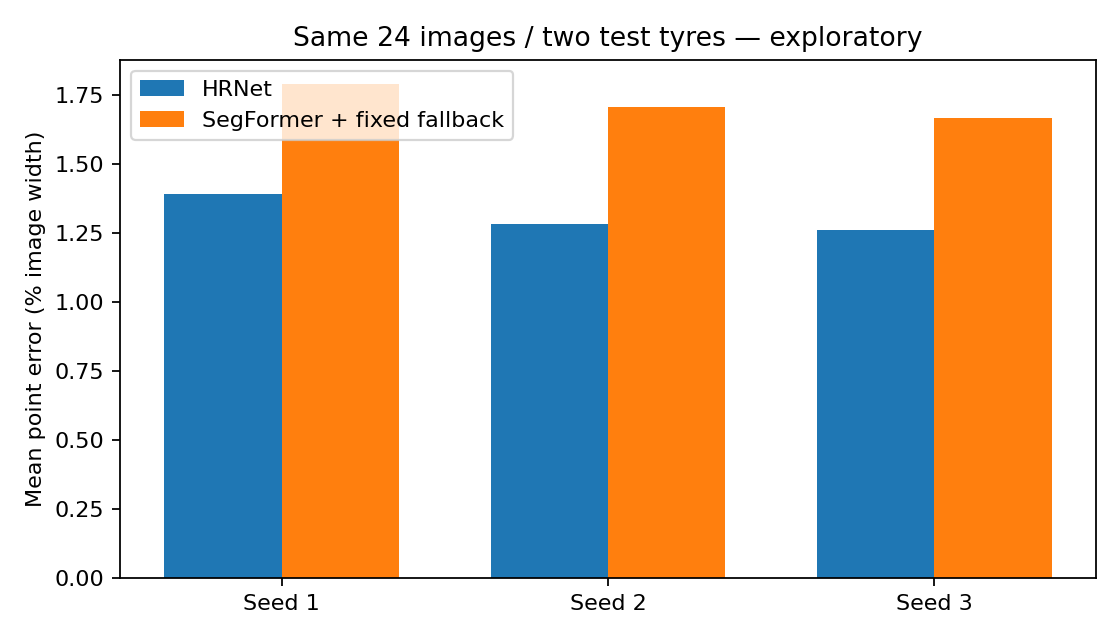

Send this executed notebook for review before deciding which geometry model to integrate.


In [7]:
from IPython.display import display, Image
for chart in (WORK/'comparison').glob('*/comparison.png'): display(Image(filename=str(chart)))
print('Send this executed notebook for review before deciding which geometry model to integrate.')
